In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from pygments.lexer import default
from scipy.integrate import simpson

from tp7.tp7 import Tape7
from srfs.srfs import SRFS
import scipy.integrate as integrate
from collections import defaultdict

In [8]:
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

# Building Dataset v1
1 tape7 file -> load tape7 file -> build scene df -> compute filtered radiances -> combine into one df

In [9]:
a00_files

['./data/Modtran_Unfiltering_Tape7s_SZA00/sno_sz00L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA00/lnd_sz00L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA00/oceclr_sz00L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA00/ocecld_sz00L.tp7',
 './data/Modtran_Unfiltering_Tape7s_SZA00/dc_sz00.spectra.tp7']

In [10]:
# a00_data = [Tape7(file) for file in a00_files]
# titles = [file.title for file in a00_data]
# a00 = {title: file for title, file in zip(titles, a00_data)}
tp7_objs = [Tape7(a00_files[1]), Tape7(a41_files[2])]
titles = [file.title for file in tp7_objs]
lnd_ocnclr = {title: file for title, file in zip(titles, tp7_objs)}
lnd_ocnclr

{'Land': <tp7.tp7.Tape7 at 0x16a24e810>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x16a24d070>}

In [11]:
land = lnd_ocnclr['Land']
ocnclr = lnd_ocnclr['Clear Ocean']

land.build_scene_description()
ocnclr.build_scene_description()
land._compute_radiences()
ocnclr._compute_radiences()

array([[[9.9999988e+02, 4.9999994e+02, 3.3333331e+02, ...,
         2.5013000e-01, 2.5006000e-01, 2.5000000e-01],
        [9.6935228e-27, 4.5194000e-25, 4.1136000e-24, ...,
         9.4496000e-12, 9.2649000e-12, 9.8272000e-12],
        [2.1349000e-08, 7.8788000e-08, 1.6570000e-07, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[9.9999988e+02, 4.9999994e+02, 3.3333331e+02, ...,
         2.5013000e-01, 2.5006000e-01, 2.5000000e-01],
        [9.6935228e-27, 4.5194000e-25, 4.1135000e-24, ...,
         9.4568000e-12, 9.2720000e-12, 9.8348000e-12],
        [2.1349000e-08, 7.8788000e-08, 1.6570000e-07, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[9.9999988e+02, 4.9999994e+02, 3.3333331e+02, ...,
         2.5013000e-01, 2.5006000e-01, 2.5000000e-01],
        [9.6935228e-27, 4.5194000e-25, 4.1135000e-24, ...,
         9.4568000e-12, 9.2720000e-12, 9.8348000e-12],
        [2.1348000e-08, 7.8788000e-08, 1.6570000e-07, ...,
         0.0000000e+00, 0

In [12]:
srf = SRFS("./data/libera_srfs_20241017.csv")

In [13]:
srf.srf_vals

,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf,End_wv_range
0,0.000000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.300000
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.301750
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006,0.303509
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933,0.305279
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865,0.307060
...,...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000,98.270641
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000,98.843745
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000,99.420192
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000,100.000000


In [14]:
tot_wvln = srf.srf_vals['wavelength [um]']
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']

In [15]:
all_integrated_radiances_land = land.integrate_radiances(tot_wvln, sw_srf, lw_srf)

In [16]:
sw_unfilt_lnd, sw_filt_land = all_integrated_radiances_land[0], all_integrated_radiances_land[2]

In [17]:
def plot_radiance(rads, title, runnum):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]
    # print('')
    # print(describer_df)
    # print(np.shape(rads))
    print(np.shape(rads), print(runnum))
    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    # ax.plot(rads[:,0,runnum], rads[:,1, runnum], 'r-', label='SW Radiance')
    ax.plot(rads[runnum, 0, :], rads[runnum, 1, :], 'r-', label='SW Radiance')
    #ax.plot(rads[:,0,runnum], rads[:,2, runnum], 'b-', label='LW Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    plt.xlim(0,5)

In [18]:
def plot_integrated_radiance(rads):
    plt.figure(figsize=(8, 4))  # Optional: Adjusts the figure size
    plt.plot(rads, marker='o', linestyle='-', label='Array Values')  # Line plot
    plt.title('1D Array Visualization')  # Add a title
    plt.xlabel('Index')  # Label for x-axis
    plt.ylabel('Value')  # Label for y-axis
    plt.grid(True)  # Add a grid
    plt.legend()  # Add a legend
    plt.show()

In [19]:
r1, r100, r250, r450, r630 = land.rads[0, 0, :], land.rads[99, 0, :], land.rads[249, 0, :], land.rads[449, 0, :], land.rads[629, 0, :]

In [20]:
set(r1) == set(r100), set(r1) == set(r250), set(r1) == set(r450), set(r1) == set(r630)

(True, True, True, True)

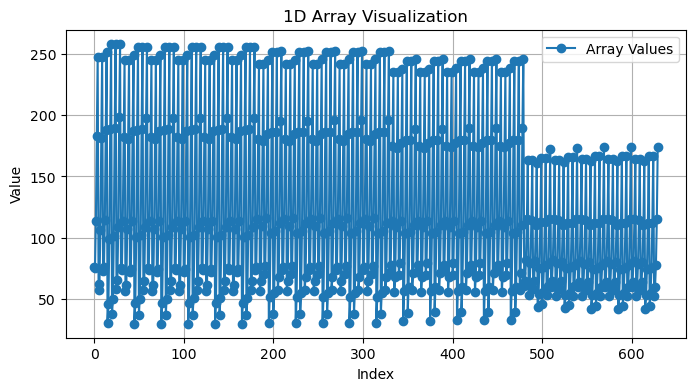

In [21]:
plot_integrated_radiance(sw_filt_land)

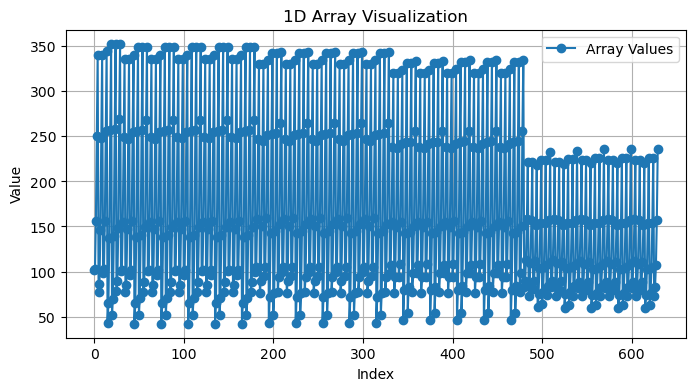

In [22]:
plot_integrated_radiance(sw_unfilt_lnd)

In [23]:
land.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Land,0.0,0.000,0.0,0,0,101.943610,98.415986,75.741646,0.016766
1,Land,0.0,0.000,0.0,1,1,103.199339,69.385728,75.312010,0.003134
2,Land,0.0,0.000,0.0,1,2,155.597301,60.639375,113.365772,0.002394
3,Land,0.0,0.000,0.0,1,3,250.690993,93.561283,183.159168,0.021286
4,Land,0.0,0.000,0.0,1,4,339.799566,86.635465,247.994888,0.029748
...,...,...,...,...,...,...,...,...,...,...
625,Land,0.0,79.914,172.5,0,625,72.435075,58.898054,52.055602,0.001229
626,Land,0.0,79.914,172.5,1,626,82.995714,46.596462,59.723925,0.002289
627,Land,0.0,79.914,172.5,1,627,106.855113,44.111228,77.231256,0.002581
628,Land,0.0,79.914,172.5,1,628,157.473747,58.363754,115.033098,0.008191


In [24]:
all_integrated_radiances_ocnclr = ocnclr.integrate_radiances(tot_wvln, sw_srf, lw_srf)

In [25]:
ocnclr.describer_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Clear Ocean,41.387,0.000,0.0,0,0,3.134961e-08,0.000568,2.121404e-08,3.962907e-11
1,Clear Ocean,41.387,0.000,0.0,0,1,3.710942e-08,0.000563,2.558854e-08,4.911216e-11
2,Clear Ocean,41.387,0.000,0.0,0,2,4.094535e-08,0.000559,2.853549e-08,5.899183e-11
3,Clear Ocean,41.387,0.000,0.0,0,3,4.838883e-08,0.000557,3.426314e-08,7.885534e-11
4,Clear Ocean,41.387,0.000,0.0,0,4,6.281120e-08,0.000556,4.537116e-08,1.186473e-10
...,...,...,...,...,...,...,...,...,...,...
142,Clear Ocean,40.375,89.947,172.5,0,142,2.035803e-07,0.000477,1.520675e-07,5.430033e-11
143,Clear Ocean,40.375,89.947,172.5,0,143,2.201035e-07,0.000477,1.652771e-07,6.450203e-11
144,Clear Ocean,40.375,89.947,172.5,0,144,2.429139e-07,0.000477,1.833745e-07,8.300935e-11
145,Clear Ocean,40.375,89.947,172.5,0,145,2.838950e-07,0.000477,2.156645e-07,1.021268e-10


In [26]:
ocnclr_lnd_df = pd.concat([land.describer_df, ocnclr.describer_df], ignore_index=True)
ocnclr_lnd_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated)
0,Land,0.000,0.000,0.0,0,0,1.019436e+02,98.415986,7.574165e+01,1.676559e-02
1,Land,0.000,0.000,0.0,1,1,1.031993e+02,69.385728,7.531201e+01,3.134451e-03
2,Land,0.000,0.000,0.0,1,2,1.555973e+02,60.639375,1.133658e+02,2.393580e-03
3,Land,0.000,0.000,0.0,1,3,2.506910e+02,93.561283,1.831592e+02,2.128643e-02
4,Land,0.000,0.000,0.0,1,4,3.397996e+02,86.635465,2.479949e+02,2.974803e-02
...,...,...,...,...,...,...,...,...,...,...
772,Clear Ocean,40.375,89.947,172.5,0,142,2.035803e-07,0.000477,1.520675e-07,5.430033e-11
773,Clear Ocean,40.375,89.947,172.5,0,143,2.201035e-07,0.000477,1.652771e-07,6.450203e-11
774,Clear Ocean,40.375,89.947,172.5,0,144,2.429139e-07,0.000477,1.833745e-07,8.300935e-11
775,Clear Ocean,40.375,89.947,172.5,0,145,2.838950e-07,0.000477,2.156645e-07,1.021268e-10


0
(630, 3, 4000) None


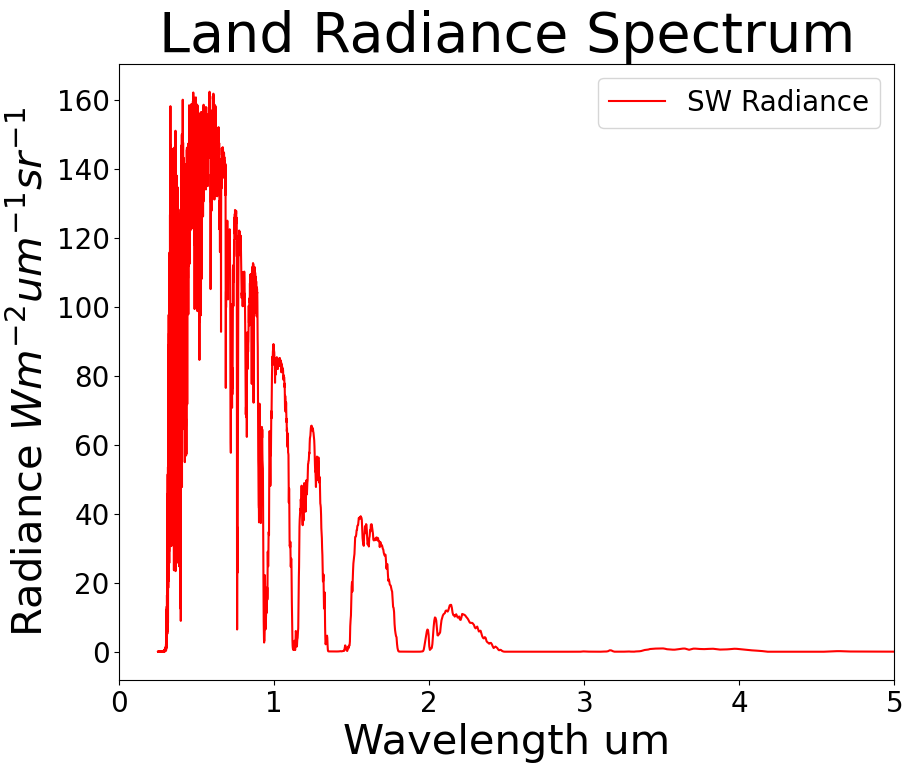

In [73]:
plot_radiance(land.rads, land.title, 0)

In [28]:
land.rads.shape

(630, 3, 4000)

In [29]:
for i in land.rads[0, 0, :]:
    print(i)

1000.0
500.0
333.3333333333333
250.0
200.0
166.66666666666666
142.85714285714286
125.0
111.11111111111111
100.0
90.9090909090909
83.33333333333333
76.92307692307693
71.42857142857143
66.66666666666667
62.5
58.8235294117647
55.55555555555556
52.63157894736842
50.0
47.61904761904762
45.45454545454545
43.47826086956522
41.666666666666664
40.0
38.46153846153847
37.03703703703704
35.714285714285715
34.48275862068965
33.333333333333336
32.25806451612903
31.25
30.303030303030305
29.41176470588235
28.571428571428573
27.77777777777778
27.027027027027028
26.31578947368421
25.641025641025642
25.0
24.390243902439025
23.80952380952381
23.25581395348837
22.727272727272727
22.22222222222222
21.73913043478261
21.27659574468085
20.833333333333332
20.408163265306126
20.0
19.607843137254903
19.230769230769234
18.867924528301888
18.51851851851852
18.181818181818183
17.857142857142858
17.54385964912281
17.241379310344826
16.949152542372882
16.666666666666668
16.39344262295082
16.129032258064516
15.87301587

In [30]:
# plot_radiance(ocnclr.rads,ocnclr.title, 0)

In [31]:
# Define the input data
data = [
    ("M1", 0.415, 0.02),
    ("M2", 0.445, 0.02),
    ("M3", 0.49, 0.02),
    ("M4", 0.555, 0.02),
    ("I1", 0.64, 0.075),
    ("M5", 0.673, 0.021),
    ("DNB", 0.7, 0.4),
    ("M6", 0.746, 0.021),
    ("I2", 0.865, 0.039),
    ("M7", 0.865, 0.039),
    ("M8", 1.24, 0.02),
    ("M9", 1.378, 0.02),
    ("I3", 1.61, 0.06),
    ("M10", 1.61, 0.06),
    ("M11", 2.25, 0.05),
    ("I4", 3.74, 0.38),
    ("M12", 3.7, 0.18),
    ("M13", 4.05, 0.155),
    ("M14", 8.55, 0.3),
    ("M15", 10.763, 1),
    ("I5", 11.45, 1.9),
    ("M16", 12.013, None),  # End width not provided
]

# Parse the data into the required array format
result = {}
for nm, center, width in data:
    if width is not None:
        start = center - width
        end = center + width
        result[nm] = (start, end)

# Display the result
result


{'M1': (0.39499999999999996, 0.435),
 'M2': (0.425, 0.465),
 'M3': (0.47, 0.51),
 'M4': (0.535, 0.5750000000000001),
 'I1': (0.5650000000000001, 0.715),
 'M5': (0.652, 0.6940000000000001),
 'DNB': (0.29999999999999993, 1.1),
 'M6': (0.725, 0.767),
 'I2': (0.826, 0.904),
 'M7': (0.826, 0.904),
 'M8': (1.22, 1.26),
 'M9': (1.3579999999999999, 1.398),
 'I3': (1.55, 1.6700000000000002),
 'M10': (1.55, 1.6700000000000002),
 'M11': (2.2, 2.3),
 'I4': (3.3600000000000003, 4.12),
 'M12': (3.52, 3.8800000000000003),
 'M13': (3.895, 4.205),
 'M14': (8.25, 8.850000000000001),
 'M15': (9.763, 11.763),
 'I5': (9.549999999999999, 13.35)}

In [32]:
# viirs_bands = [(0.39499999999999996, 0.435),
#  (0.425, 0.465),
#  (0.47, 0.51),
#  (0.535, 0.5750000000000001),
#  (0.5650000000000001, 0.715),
#  (0.652, 0.6940000000000001),
#  (0.29999999999999993, 1.1),
#  (0.725, 0.767),
#  (0.826, 0.904),
#  (0.826, 0.904),
#  (1.22, 1.26),
#  (1.3579999999999999, 1.398),
#  (1.55, 1.6700000000000002),
#  (1.55, 1.6700000000000002),
#  (2.2, 2.3),
#  (3.3600000000000003, 4.12),
#  (3.52, 3.8800000000000003),
#  (3.895, 4.205),
#  (8.25, 8.850000000000001),
#  (9.763, 11.763),
#  (9.549999999999999, 13.35)]
# viirs_bands = viirs_bands[::-1]
# viirs_bands, np.shape(viirs_bands)

([(9.549999999999999, 13.35),
  (9.763, 11.763),
  (8.25, 8.850000000000001),
  (3.895, 4.205),
  (3.52, 3.8800000000000003),
  (3.3600000000000003, 4.12),
  (2.2, 2.3),
  (1.55, 1.6700000000000002),
  (1.55, 1.6700000000000002),
  (1.3579999999999999, 1.398),
  (1.22, 1.26),
  (0.826, 0.904),
  (0.826, 0.904),
  (0.725, 0.767),
  (0.29999999999999993, 1.1),
  (0.652, 0.6940000000000001),
  (0.5650000000000001, 0.715),
  (0.535, 0.5750000000000001),
  (0.47, 0.51),
  (0.425, 0.465),
  (0.39499999999999996, 0.435)],
 (21, 2))

In [33]:
viirs_bands = result

In [34]:
viirs_bands

{'M1': (0.39499999999999996, 0.435),
 'M2': (0.425, 0.465),
 'M3': (0.47, 0.51),
 'M4': (0.535, 0.5750000000000001),
 'I1': (0.5650000000000001, 0.715),
 'M5': (0.652, 0.6940000000000001),
 'DNB': (0.29999999999999993, 1.1),
 'M6': (0.725, 0.767),
 'I2': (0.826, 0.904),
 'M7': (0.826, 0.904),
 'M8': (1.22, 1.26),
 'M9': (1.3579999999999999, 1.398),
 'I3': (1.55, 1.6700000000000002),
 'M10': (1.55, 1.6700000000000002),
 'M11': (2.2, 2.3),
 'I4': (3.3600000000000003, 4.12),
 'M12': (3.52, 3.8800000000000003),
 'M13': (3.895, 4.205),
 'M14': (8.25, 8.850000000000001),
 'M15': (9.763, 11.763),
 'I5': (9.549999999999999, 13.35)}

In [48]:
viirs_rads_indxs = defaultdict(list)
wv_00 = land.rads[0, 0, :]
vb_idx = 0
idx = 0
check = 0
for band, rng in viirs_bands.items():
    temp = []
    for idx in range(len(wv_00)):
        check += 1
        if rng[0] <= wv_00[idx] <= rng[1]:
            temp.append(idx)
    if temp:
        viirs_rads_indxs[band].append(temp[0])
        viirs_rads_indxs[band].append(temp[-1])

check % 4000

0

In [49]:
viirs_rads_indxs

defaultdict(list,
            {'M1': [2298, 2530],
             'M2': [2150, 2351],
             'M3': [1960, 2126],
             'M4': [1739, 1868],
             'I1': [1398, 1768],
             'M5': [1440, 1532],
             'DNB': [909, 3332],
             'M6': [1303, 1378],
             'I2': [1106, 1209],
             'M7': [1106, 1209],
             'M8': [793, 818],
             'M9': [715, 735],
             'I3': [598, 644],
             'M10': [598, 644],
             'M11': [434, 453],
             'I4': [242, 296],
             'M12': [257, 283],
             'M13': [237, 255],
             'M14': [112, 120],
             'M15': [85, 101],
             'I5': [74, 103]})

In [50]:
sw_00 = land.rads[0, 1, :]

In [51]:
m1 = viirs_rads_indxs["M1"]
sw_00[m1[0]], sw_00[m1[1]]

(112.9617043324, 102.4787205014)

In [58]:
y_vals = sw_00[m1[0]: m1[1] + 1]
x_vals = wv_00[m1[0]: m1[1] + 1]
m1_integrated = integrate.simpson(y=y_vals, x=x_vals)

In [59]:
m1_integrated

-4.4424153031346405

In [78]:
sw_int = []
for band, rng in viirs_rads_indxs.items():
    # print(rng)
    y_vals = sw_00[rng[0]: rng[1] + 1]
    x_vals = wv_00[rng[0]: rng[1] + 1]
    sw_int.append(-integrate.simpson(y=y_vals, x=x_vals))

sw_int

[4.4424153031346405,
 5.00383648486101,
 5.7806540011802365,
 5.84452380415585,
 20.733589006148534,
 5.553766863009579,
 80.90467898409432,
 4.0313719353207675,
 7.420257148330847,
 7.420257148330847,
 2.3958666905711854,
 0.0025924668867464045,
 4.098688924271809,
 4.098688924271809,
 0.8887218027463042,
 0.5375098998111691,
 0.27094931662994554,
 0.14251443661742774,
 0.002907707648732562,
 0.0033329015049323903,
 0.004050872104815021]

In [79]:
sum(sw_int)

159.58117462163156

In [80]:
integrate.simpson(y=sw_00, x=wv_00)

-101.9436101969154

In [64]:
wv_00.shape, sw_00.shape

((4000,), (4000,))

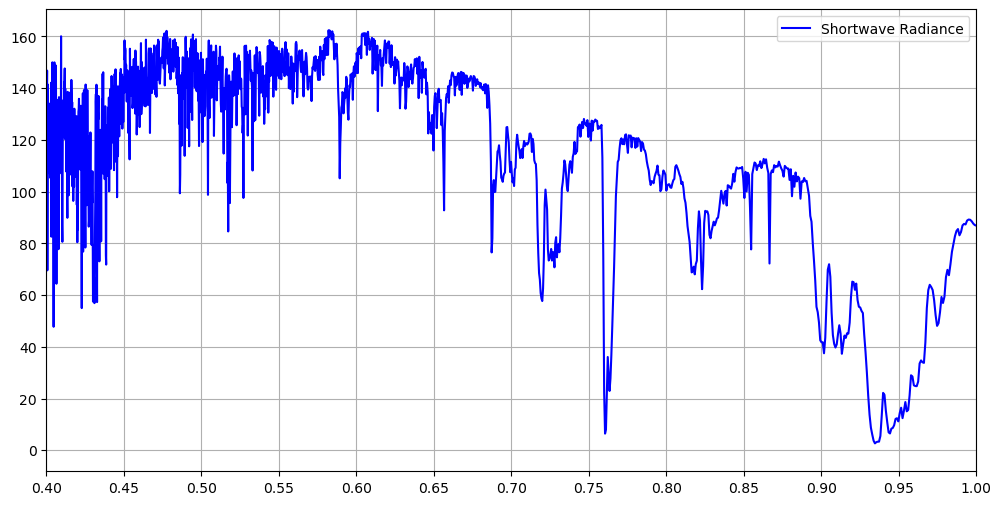

In [65]:
plt.figure(figsize=(12, 6))
x_min = 0.4
x_max = 1.0
tick_interval = 0.05

plt.plot(wv_00, sw_00, label="Shortwave Radiance", color='blue')
plt.xlim(x_min, x_max)


x_ticks = np.arange(x_min, x_max + tick_interval, tick_interval)
plt.xticks(x_ticks)

plt.grid(True)
plt.legend(loc="upper right")
plt.show()